# **Madrid**
## **Desenvolupament dels models**
Aquest Notebook s'ha refet per a entendre el desenvolupment dels 12 models de Machine Learning.

#### **Importem les llibreries**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
pd.set_option('future.no_silent_downcasting', True)

#### **Importem les dades**
"TF Dades EDA.csv" és el csv que surt del 1. Notebook_Madrid_Tractament_Dades.ipynb, i que s'utilitza en "2. Notebook_Madrid_EDA.ipynb" <br>
És el csv que ve després d'haver processat les dades.

In [5]:
df = pd.read_csv('/content/drive/MyDrive/IgniteAI/Proyecto_Inmobiliaria/03. Datos/Madrid/Tablas Transformadas/TF Dades EDA.csv', index_col='Unnamed: 0')

## Conclusió: Fer 12 models. <br>
- 10 per a districtes de Madrid
- 1 per a Alcala de Henares
- 1 per a Mostoles.

In [6]:
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,0,0,0,1,1,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608,2.236608,2.717073
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,1,1,0,0,1,"['91 m² construidos, 73 m² útiles', '2 habitac...",274900,2.236608,2.236608,2.717073
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,0,0,0,1,1,"['Chalet adosado', '268 m² construidos, 254 m²...",519000,2.236608,2.236608,1.948505


In [7]:
df.describe().T.loc[:, ['max']]

,max
sku,1.067068e+08
metros_cuadrados,9.950000e+02
tipo_vivienda,4.000000e+00
habitaciones,8.000000e+00
ban,8.000000e+00
planta,8.000000e+00
terraza,1.000000e+00
balcon,1.000000e+00
ascensor,1.000000e+00
casa_plantas,5.000000e+00


In [8]:
df.head(1).T

,0
sku,100848270
metros_cuadrados,237
calle,Casco histórico
barrio,Alcalá de Henares
distrito,Alcalá de Henares
ciudad,Alcalá de Henares
tipo_vivienda,4.0
habitaciones,4
ban,1
planta,4


Definim els grups

In [9]:
grupo_1 = ['Salamanca', 'Retiro']
grupo_2 = ['Chamberí', 'Chamartín']
grupo_3 = ['Centro']
grupo_4 = ['Moncloa-Aravaca', 'Fuencarral-El Pardo']
grupo_5 = ['Tetuán']
grupo_6 = ['Hortaleza', 'Ciudad Lineal']
grupo_7 = ['Barajas', 'San Blas-Canillejas', 'Latina']
grupo_8 = ['Carabanchel']
grupo_9 = ['Arganzuela']
grupo_10 = ['Vicálvaro', 'Usera', 'Moratalaz', 'Puente de Vallecas', 'Villaverde']
grupo_11 = ['Alcalá de Henares']
grupo_12 = ['Móstoles']

Mostrem per pantalla els grups dels districtes, on es desenvoluparan els models.

In [10]:
i=1
print(f'grupo {i}: {grupo_1}')
i+=1
print(f'grupo {i}: {grupo_2}')
i+=1
print(f'grupo {i}: {grupo_3}')
i+=1
print(f'grupo {i}: {grupo_4}')
i+=1
print(f'grupo {i}: {grupo_5}')
i+=1
print(f'grupo {i}: {grupo_6}')
i+=1
print(f'grupo {i}: {grupo_7}')
i+=1
print(f'grupo {i}: {grupo_8}')
i+=1
print(f'grupo {i}: {grupo_9}')
i+=1
print(f'grupo {i}: {grupo_10}')
i+=1
print(f'grupo {i}: {grupo_11}')
i+=1
print(f'grupo {i}: {grupo_12}')
i+=1


grupo 1: ['Salamanca', 'Retiro']
grupo 2: ['Chamberí', 'Chamartín']
grupo 3: ['Centro']
grupo 4: ['Moncloa-Aravaca', 'Fuencarral-El Pardo']
grupo 5: ['Tetuán']
grupo 6: ['Hortaleza', 'Ciudad Lineal']
grupo 7: ['Barajas', 'San Blas-Canillejas', 'Latina']
grupo 8: ['Carabanchel']
grupo 9: ['Arganzuela']
grupo 10: ['Vicálvaro', 'Usera', 'Moratalaz', 'Puente de Vallecas', 'Villaverde']
grupo 11: ['Alcalá de Henares']
grupo 12: ['Móstoles']


In [11]:
lista_valor_distrito = []

for i in df.index:
    if df.loc[i,'distrito'] in grupo_1:
        valor_distrito = 1
    elif df.loc[i,'distrito'] in grupo_2:
        valor_distrito = 2
    elif df.loc[i,'distrito'] in grupo_3:
        valor_distrito = 3
    elif df.loc[i,'distrito'] in grupo_4:
        valor_distrito = 4
    elif df.loc[i,'distrito'] in grupo_5:
        valor_distrito = 5
    elif df.loc[i,'distrito'] in grupo_6:
        valor_distrito = 6
    elif df.loc[i,'distrito'] in grupo_7:
        valor_distrito = 7
    elif df.loc[i,'distrito'] in grupo_8:
        valor_distrito = 8
    elif df.loc[i,'distrito'] in grupo_9:
        valor_distrito = 9
    elif df.loc[i,'distrito'] in grupo_10:
        valor_distrito = 10
    elif df.loc[i,'ciudad'] in grupo_11:
        valor_distrito = 11
    elif df.loc[i,'ciudad'] in grupo_12:
        valor_distrito = 12
    lista_valor_distrito.append(valor_distrito)

In [12]:
df['distrito_valor'] = lista_valor_distrito

In [13]:
df.shape

(9894, 21)

In [14]:
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,...,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle,distrito_valor
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,...,0,0,1,1,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608,2.236608,2.717073,11
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,...,1,0,0,1,"['91 m² construidos, 73 m² útiles', '2 habitac...",274900,2.236608,2.236608,2.717073,11
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,...,0,0,1,1,"['Chalet adosado', '268 m² construidos, 254 m²...",519000,2.236608,2.236608,1.948505,11


In [15]:
df['distrito_valor'].isna().sum()

np.int64(0)

In [16]:
df_modelo = df[[
                'distrito_valor',
                'metros_cuadrados',
                'precio_m2_distrito',
                'precio_m2_barrio',
                'precio_m2_calle',
                'tipo_vivienda',
                'habitaciones',
                'ban',
                'planta',
                'terraza',
                'balcon',
                'ascensor',
                'estado_obra',
                'precio'
]]

df_modelo.head(1)

,distrito_valor,metros_cuadrados,precio_m2_distrito,precio_m2_barrio,precio_m2_calle,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,estado_obra,precio
0,11,237,2.236608,2.236608,2.717073,4.0,4,1,4,0,0,0,1,616300


In [17]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9894 entries, 0 to 9894
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   distrito_valor      9894 non-null   int64  
 1   metros_cuadrados    9894 non-null   int64  
 2   precio_m2_distrito  9894 non-null   float64
 3   precio_m2_barrio    9894 non-null   float64
 4   precio_m2_calle     9894 non-null   float64
 5   tipo_vivienda       9894 non-null   float64
 6   habitaciones        9894 non-null   int64  
 7   ban                 9894 non-null   int64  
 8   planta              9894 non-null   int64  
 9   terraza             9894 non-null   int64  
 10  balcon              9894 non-null   int64  
 11  ascensor            9894 non-null   int64  
 12  estado_obra         9894 non-null   int64  
 13  precio              9894 non-null   int64  
dtypes: float64(4), int64(10)
memory usage: 1.4 MB


#### **Test estadístics**

In [18]:
df_modelo_numeric = df_modelo.iloc[:, [1,2,3,4,13]]
df_modelo_numeric.head(3)

,metros_cuadrados,precio_m2_distrito,precio_m2_barrio,precio_m2_calle,precio
0,237,2.236608,2.236608,2.717073,616300
1,91,2.236608,2.236608,2.717073,274900
2,268,2.236608,2.236608,1.948505,519000


In [19]:
df_modelo_categoric = df_modelo.iloc[:, 5:]
df_modelo_categoric.head(3)

,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,estado_obra,precio
0,4.0,4,1,4,0,0,0,1,616300
1,1.0,2,1,2,1,1,0,1,274900
2,4.0,4,3,4,0,0,0,1,519000


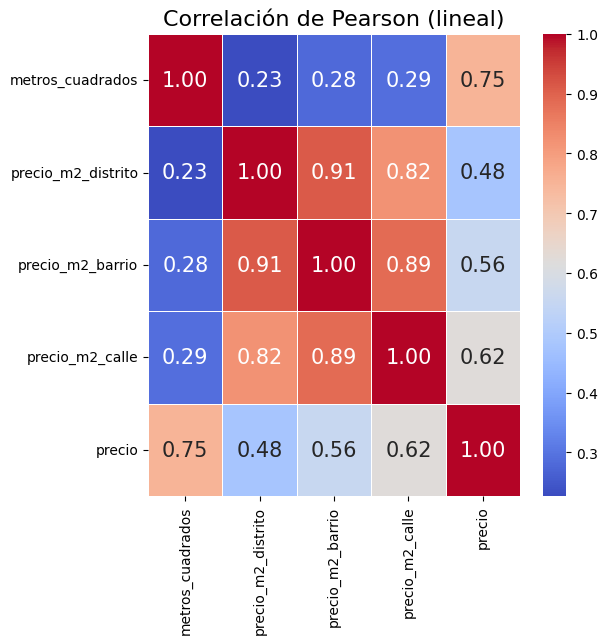

In [20]:
#correlation_matrix = df.corr()
correlation_matrix_1 = df_modelo_numeric.corr(method='pearson')

plt.figure(figsize=(6, 6))

# Crear un mapa de calor
sns.heatmap(correlation_matrix_1, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 15})
plt.title('Correlación de Pearson (lineal)', fontsize=16)

plt.show()

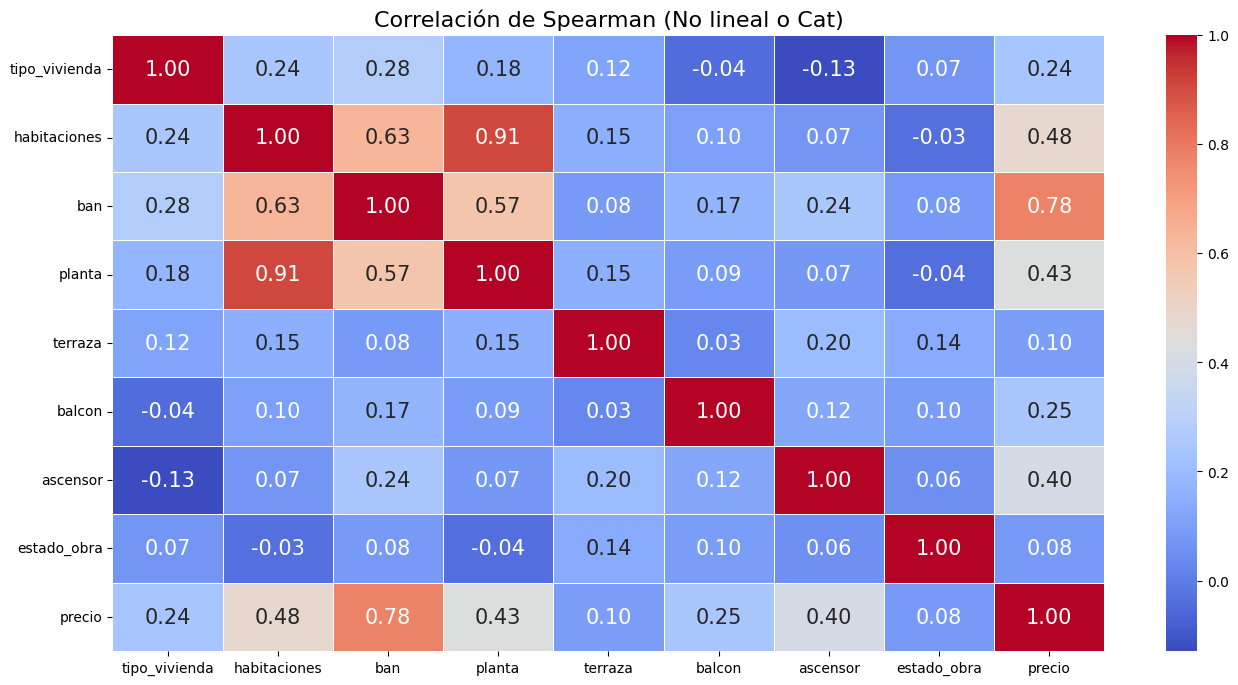

In [21]:
#correlation_matrix = df.corr()
correlation_matrix_2 = df_modelo_categoric.corr(method='spearman')

plt.figure(figsize=(16, 8))

# Crear un mapa de calor
sns.heatmap(correlation_matrix_2, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 15})
plt.title('Correlación de Spearman (No lineal o Cat)', fontsize=16)

plt.show()

In [22]:
import scipy as sp

target = 'precio'
f_list = []
r_list = []
p_list = []

for field in df_modelo_categoric:
    r, pvalue = sp.stats.spearmanr(df_modelo_categoric[field], df_modelo_categoric[target])
    f_list.append(field)
    r_list.append(r)
    p_list.append(pvalue)

df_correlation = pd.DataFrame({'variable': f_list, 'correlation': r_list, 'pvalue': p_list})

df_correlation = df_correlation.sort_values(by='correlation', ascending=False)
df_correlation


,variable,correlation,pvalue
8,precio,1.000000,0.000000e+00
2,ban,0.777161,0.000000e+00
1,habitaciones,0.475323,0.000000e+00
3,planta,0.433418,0.000000e+00
6,ascensor,0.404257,0.000000e+00
5,balcon,0.245703,5.734562e-136
0,tipo_vivienda,0.237242,1.243262e-126
4,terraza,0.095707,1.420404e-21
7,estado_obra,0.083860,6.536285e-17


In [23]:
#df_correlation[ df_correlation['pvalue'] < 0.05 ]

### **Guardar dades del model**

In [24]:
#df.to_csv('/content/drive/MyDrive/IgniteAI/Proyecto_Inmobiliaria/03. Datos/Madrid/Tablas Transformadas/TF Dades Models.csv', index=False, encoding='utf-8')

## **Desenvolupament del model**

In [25]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [26]:
df = pd.read_csv('/content/drive/MyDrive/IgniteAI/Proyecto_Inmobiliaria/03. Datos/Madrid/Tablas Transformadas/TF Dades Models.csv', encoding='utf-8')

In [27]:
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,...,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle,distrito_valor
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,...,0,0,1,1,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608,2.236608,2.717073,11
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,...,1,0,0,1,"['91 m² construidos, 73 m² útiles', '2 habitac...",274900,2.236608,2.236608,2.717073,11
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,...,0,0,1,1,"['Chalet adosado', '268 m² construidos, 254 m²...",519000,2.236608,2.236608,1.948505,11


#### **Preparem el df per al model**

In [28]:
df_modelo = df[[
                'distrito_valor',
                'metros_cuadrados',
                'precio_m2_distrito',
                'precio_m2_barrio',
                'precio_m2_calle',
                'tipo_vivienda',
                'habitaciones',
                'ban',
                'planta',
                'terraza',
                'balcon',
                'ascensor',
                'estado_obra',
                'precio'
]]

df_modelo.head(1)

,distrito_valor,metros_cuadrados,precio_m2_distrito,precio_m2_barrio,precio_m2_calle,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,estado_obra,precio
0,11,237,2.236608,2.236608,2.717073,4.0,4,1,4,0,0,0,1,616300


#### **Importem les funcions per al model**

In [29]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import datasets, ensemble
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.utils.fixes import parse_version
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder


In [30]:
def modelo_rf(df_input):
    X = df_input.iloc[:, :-1].values
    y = df_input['precio'].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    y_pred_rf = rf.predict(X_test)

    # Calcular MAE (Mean Absolute Error)
    mae_rf = mean_absolute_error(y_test, y_pred_rf)

    # Calcular MSE (Mean Squared Error)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    rmse_rf = np.sqrt(mse_rf)/y_test.mean()*100

    # Calcular R² (Coeficiente de determinación)
    r2_rf = r2_score(y_test, y_pred_rf)

    # Imprimir los resultados
    print(f"MAE (Mean Absolute Error): {mae_rf}")
    print(f"MSE (Mean Squared Error): {mse_rf}")
    print(f"RMSE (Root Mean Squared Error): {rmse_rf:.1f} %")
    print(f"R² (Coeficiente de Determinación): {r2_rf}")

    return rf


In [31]:
from sklearn.linear_model import LinearRegression

def modelo_rf_2(df_input):
    X = df_input.loc[:, 'precio_m2_calle'].values
    y = df_input['precio'].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
    X_train = X_train.reshape(-1, 1)
    X_test = X_test.reshape(-1, 1)

    # Linear regressor
    rf = LinearRegression()
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    # Calcular MAE (Mean Absolute Error)
    mae_rf = mean_absolute_error(y_test, y_pred_rf)

    # Calcular MSE (Mean Squared Error)
    mse_rf = mean_squared_error(y_test, y_pred_rf)
    rmse_rf = np.sqrt(mse_rf)/y_test.mean()*100

    # Calcular R² (Coeficiente de determinación)
    r2_rf = r2_score(y_test, y_pred_rf)

    # Imprimir los resultados
    print(f"MAE (Mean Absolute Error): {mae_rf}")
    print(f"MSE (Mean Squared Error): {mse_rf}")
    print(f"RMSE (Root Mean Squared Error): {rmse_rf:.1f} %")
    print(f"R² (Coeficiente de Determinación): {r2_rf}")

    return rf


#### **Passem els grups als models**

In [32]:
df_modelo.head(3)

,distrito_valor,metros_cuadrados,precio_m2_distrito,precio_m2_barrio,precio_m2_calle,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,estado_obra,precio
0,11,237,2.236608,2.236608,2.717073,4.0,4,1,4,0,0,0,1,616300
1,11,91,2.236608,2.236608,2.717073,1.0,2,1,2,1,1,0,1,274900
2,11,268,2.236608,2.236608,1.948505,4.0,4,3,4,0,0,0,1,519000


In [33]:
df_1 = df_modelo[df_modelo['distrito_valor'] == 1].iloc[:,1:]
df_2 = df_modelo[df_modelo['distrito_valor'] == 2].iloc[:,1:]
df_3 = df_modelo[df_modelo['distrito_valor'] == 3].iloc[:,1:]
df_4 = df_modelo[df_modelo['distrito_valor'] == 4].iloc[:,1:]
df_5 = df_modelo[df_modelo['distrito_valor'] == 5].iloc[:,1:]
df_6 = df_modelo[df_modelo['distrito_valor'] == 6].iloc[:,1:]
df_7 = df_modelo[df_modelo['distrito_valor'] == 7].iloc[:,1:]
df_8 = df_modelo[df_modelo['distrito_valor'] == 8].iloc[:,1:]
df_9 = df_modelo[df_modelo['distrito_valor'] == 9].iloc[:,1:]
df_10 = df_modelo[df_modelo['distrito_valor'] == 10].iloc[:,1:]
df_11 = df_modelo[df_modelo['distrito_valor'] == 11].iloc[:,1:]
df_12 = df_modelo[df_modelo['distrito_valor'] == 12].iloc[:,1:]


In [34]:
modelo_1 = modelo_rf(df_1)


MAE (Mean Absolute Error): 255723.89118027806
MSE (Mean Squared Error): 296941609997.3379
RMSE (Root Mean Squared Error): 29.9 %
R² (Coeficiente de Determinación): 0.9290986643582734


In [35]:
modelo_2 = modelo_rf(df_2)

MAE (Mean Absolute Error): 236834.1516339869
MSE (Mean Squared Error): 464873687918.6166
RMSE (Root Mean Squared Error): 43.0 %
R² (Coeficiente de Determinación): 0.81568637786472


In [36]:
modelo_3 = modelo_rf(df_3)

MAE (Mean Absolute Error): 131832.47998911148
MSE (Mean Squared Error): 61896319324.61594
RMSE (Root Mean Squared Error): 30.9 %
R² (Coeficiente de Determinación): 0.8386659914801884


In [37]:
modelo_4 = modelo_rf(df_4)

MAE (Mean Absolute Error): 178869.21565656565
MSE (Mean Squared Error): 64039783149.54801
RMSE (Root Mean Squared Error): 19.0 %
R² (Coeficiente de Determinación): 0.9457323585782775


In [38]:
modelo_5 = modelo_rf(df_5)

MAE (Mean Absolute Error): 87446.61070257613
MSE (Mean Squared Error): 27720068588.261154
RMSE (Root Mean Squared Error): 26.4 %
R² (Coeficiente de Determinación): 0.8901469947040278


In [39]:
modelo_6 = modelo_rf(df_6)

MAE (Mean Absolute Error): 61806.241105718356
MSE (Mean Squared Error): 9128804189.374882
RMSE (Root Mean Squared Error): 18.7 %
R² (Coeficiente de Determinación): 0.9450214530620318


In [40]:
modelo_7 = modelo_rf(df_7)

MAE (Mean Absolute Error): 43707.403449370075
MSE (Mean Squared Error): 7478003855.653905
RMSE (Root Mean Squared Error): 22.3 %
R² (Coeficiente de Determinación): 0.912146555265455


In [41]:
modelo_8 = modelo_rf(df_8)

MAE (Mean Absolute Error): 38016.71294871795
MSE (Mean Squared Error): 3539471994.9177465
RMSE (Root Mean Squared Error): 22.1 %
R² (Coeficiente de Determinación): 0.7925894828733115


In [42]:
modelo_9 = modelo_rf(df_9)

MAE (Mean Absolute Error): 53530.16902494331
MSE (Mean Squared Error): 8605162641.086538
RMSE (Root Mean Squared Error): 20.3 %
R² (Coeficiente de Determinación): 0.8719490499121013


In [43]:
modelo_10 = modelo_rf(df_10)

MAE (Mean Absolute Error): 35362.78976638504
MSE (Mean Squared Error): 4291076291.9388723
RMSE (Root Mean Squared Error): 29.4 %
R² (Coeficiente de Determinación): 0.7148828389607478


In [44]:
modelo_11 = modelo_rf(df_11)
#modelo_11 = modelo_rf_2(df_11)

MAE (Mean Absolute Error): 30691.928947368415
MSE (Mean Squared Error): 1473731984.0423212
RMSE (Root Mean Squared Error): 15.2 %
R² (Coeficiente de Determinación): 0.9250798289812033


In [45]:
modelo_12 = modelo_rf(df_12)
#modelo_12 = modelo_rf_2(df_12)

MAE (Mean Absolute Error): 48865.77420408162
MSE (Mean Squared Error): 3761242832.3849936
RMSE (Root Mean Squared Error): 16.6 %
R² (Coeficiente de Determinación): 0.8309842729377357


## Guardar modelos

In [46]:
import joblib

joblib.dump(modelo_1,   "modelos/modelo_1.pkl")
joblib.dump(modelo_2,   "modelos/modelo_2.pkl")
joblib.dump(modelo_3,   "modelos/modelo_3.pkl")
joblib.dump(modelo_4,   "modelos/modelo_4.pkl")
joblib.dump(modelo_5,   "modelos/modelo_5.pkl")
joblib.dump(modelo_6,   "modelos/modelo_6.pkl")
joblib.dump(modelo_7,   "modelos/modelo_7.pkl")
joblib.dump(modelo_8,   "modelos/modelo_8.pkl")
joblib.dump(modelo_9,   "modelos/modelo_9.pkl")
joblib.dump(modelo_10,  "modelos/modelo_10.pkl")
joblib.dump(modelo_11,  "modelos/modelo_11.pkl")
joblib.dump(modelo_12,  "modelos/modelo_12.pkl")


FileNotFoundError: [Errno 2] No such file or directory: 'modelos/modelo_1.pkl'

## Predecir toda la base

In [47]:
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,...,balcon,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle,distrito_valor
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,...,0,0,1,1,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608,2.236608,2.717073,11
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,...,1,0,0,1,"['91 m² construidos, 73 m² útiles', '2 habitac...",274900,2.236608,2.236608,2.717073,11
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,...,0,0,1,1,"['Chalet adosado', '268 m² construidos, 254 m²...",519000,2.236608,2.236608,1.948505,11


In [48]:
df.head(1).T

,0
sku,100848270
metros_cuadrados,237
calle,Casco histórico
barrio,Alcalá de Henares
distrito,Alcalá de Henares
ciudad,Alcalá de Henares
tipo_vivienda,4.0
habitaciones,4
ban,1
planta,4


## Antes
- tipo_vivienda	index
- 0	Estudio	0
- 1	Piso	1
- 2	Chalet adosado	2
- 3	Duplex	3
- 4	Atico	4
- 5	Chalet pareado	5
- 6	Casa o chalet	6
## Ahora
- tipo_vivienda	index
- 0	Estudio	0
- 1	Piso	1
- 2	Duplex	2
- 3	Atico	3
- 4	Casa/Chalet	4


In [49]:
lista_tipo_vivienda = []

for i in np.arange(0, len(df)):
    if df.loc[i,'tipo_vivienda'] == 0:
        tipo = 'Estudio'
    elif df.loc[i,'tipo_vivienda'] == 1:
        tipo = 'Piso'
    elif df.loc[i,'tipo_vivienda'] == 2:
        tipo = 'Duplex'
    elif df.loc[i,'tipo_vivienda'] == 3:
        tipo = 'Atico'
    elif df.loc[i,'tipo_vivienda'] == 4:
        tipo = 'Casa/Chalet'

    lista_tipo_vivienda.append(tipo)


In [50]:
df['tipo_vivienda_desc'] = lista_tipo_vivienda

In [51]:
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,...,ascensor,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle,distrito_valor,tipo_vivienda_desc
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,...,0,1,1,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608,2.236608,2.717073,11,Casa/Chalet
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,...,0,0,1,"['91 m² construidos, 73 m² útiles', '2 habitac...",274900,2.236608,2.236608,2.717073,11,Piso
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,...,0,1,1,"['Chalet adosado', '268 m² construidos, 254 m²...",519000,2.236608,2.236608,1.948505,11,Casa/Chalet


In [52]:
df_modelo.head(3)

,distrito_valor,metros_cuadrados,precio_m2_distrito,precio_m2_barrio,precio_m2_calle,tipo_vivienda,habitaciones,ban,planta,terraza,balcon,ascensor,estado_obra,precio
0,11,237,2.236608,2.236608,2.717073,4.0,4,1,4,0,0,0,1,616300
1,11,91,2.236608,2.236608,2.717073,1.0,2,1,2,1,1,0,1,274900
2,11,268,2.236608,2.236608,1.948505,4.0,4,3,4,0,0,0,1,519000


In [53]:
df_modelo.shape

(9894, 14)

In [54]:
X = df.loc[0, ['metros_cuadrados', 'precio_m2_distrito', 'precio_m2_barrio', 'precio_m2_calle', 'tipo_vivienda', 'habitaciones',
               'ban',               'planta',            'terraza',          'balcon',          'ascensor',       'estado_obra']].values.reshape(1, -1)

X

array([[np.int64(237), np.float64(2.2366083064279425),
        np.float64(2.2366083064279425), np.float64(2.717073170731707),
        np.float64(4.0), np.int64(4), np.int64(1), np.int64(4),
        np.int64(0), np.int64(0), np.int64(0), np.int64(1)]], dtype=object)

## Grupo

In [55]:
grupo_1 = ['Salamanca', 'Retiro']
grupo_2 = ['Chamberí', 'Chamartín']
grupo_3 = ['Centro']
grupo_4 = ['Moncloa-Aravaca', 'Fuencarral-El Pardo']
grupo_5 = ['Tetuán']
grupo_6 = ['Hortaleza', 'Ciudad Lineal']
grupo_7 = ['Barajas', 'San Blas-Canillejas', 'Latina']
grupo_8 = ['Carabanchel']
grupo_9 = ['Arganzuela']
grupo_10 = ['Vicálvaro', 'Usera', 'Moratalaz', 'Puente de Vallecas', 'Villaverde']
grupo_11 = ['Alcalá de Henares']
grupo_12 = ['Móstoles']


## Pasar el modelo

In [56]:
lista_precio_pred = []

for i in np.arange(0, len(df)):
    X = df.loc[i, ['metros_cuadrados', 'precio_m2_distrito', 'precio_m2_barrio', 'precio_m2_calle',
                   'tipo_vivienda',    'habitaciones',       'ban',              'planta',
                   'terraza',          'balcon',             'ascensor',         'estado_obra']].values.reshape(1, -1)

    if df.loc[i,'distrito'] in grupo_1:
        precio_pred = modelo_1.predict(X)

    elif df.loc[i,'distrito'] in grupo_2:
        precio_pred = modelo_2.predict(X)

    elif df.loc[i,'distrito'] in grupo_3:
       precio_pred = modelo_3.predict(X)

    elif df.loc[i,'distrito'] in grupo_4:
        precio_pred = modelo_4.predict(X)

    elif df.loc[i,'distrito'] in grupo_5:
        precio_pred = modelo_5.predict(X)

    elif df.loc[i,'distrito'] in grupo_6:
        precio_pred = modelo_6.predict(X)

    elif df.loc[i,'distrito'] in grupo_7:
        precio_pred = modelo_7.predict(X)

    elif df.loc[i,'distrito'] in grupo_8:
        precio_pred = modelo_8.predict(X)

    elif df.loc[i,'distrito'] in grupo_9:
        precio_pred = modelo_9.predict(X)

    elif df.loc[i,'distrito'] in grupo_10:
        precio_pred = modelo_10.predict(X)

    elif df.loc[i,'distrito'] in grupo_11:
        precio_pred = modelo_11.predict(X)

    elif df.loc[i,'distrito'] in grupo_12:
        precio_pred = modelo_12.predict(X)

    lista_precio_pred.append(precio_pred)



In [57]:
valores = [arr[0] for arr in lista_precio_pred]
df['precio_pred'] = valores


In [58]:
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,...,casa_plantas,estado_obra,caracteristicas_basicas,precio,precio_m2_barrio,precio_m2_distrito,precio_m2_calle,distrito_valor,tipo_vivienda_desc,precio_pred
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,...,1,1,"['Casa o chalet', '237 m² construidos, 232 m² ...",616300,2.236608,2.236608,2.717073,11,Casa/Chalet,594971.39
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,...,0,1,"['91 m² construidos, 73 m² útiles', '2 habitac...",274900,2.236608,2.236608,2.717073,11,Piso,252110.00
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,...,1,1,"['Chalet adosado', '268 m² construidos, 254 m²...",519000,2.236608,2.236608,1.948505,11,Casa/Chalet,523399.40


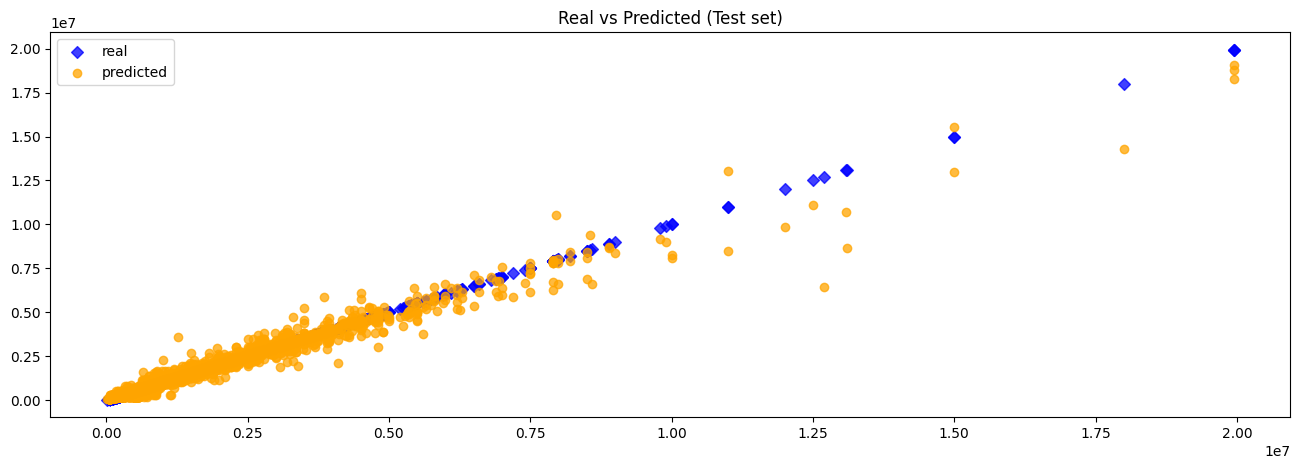

In [59]:
plt.figure(figsize=(16, 5))

plt.scatter(df['precio'], df['precio'], color = 'blue', marker='D', label='real', alpha=0.75)
plt.scatter(df['precio'], df['precio_pred'], color = 'orange', marker='o', label='predicted', alpha=0.75)
plt.title('Real vs Predicted (Test set)')
plt.legend()
plt.show()

<Axes: xlabel='precio', ylabel='precio'>

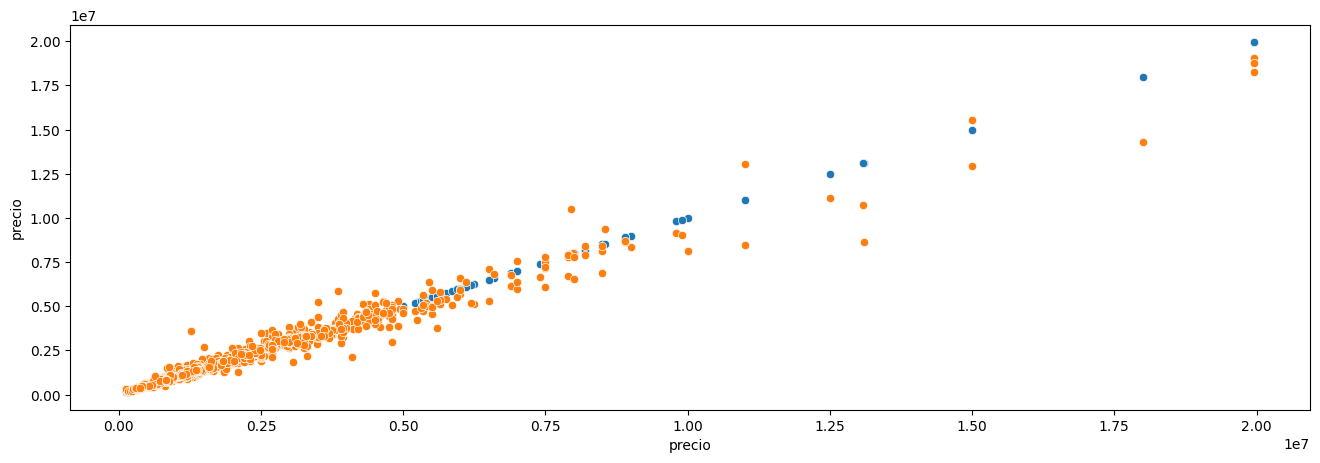

In [60]:
plt.figure(figsize=(16, 5))

sns.scatterplot(x='precio', y='precio', data=df[
                (df['distrito_valor'] == 1) ])
sns.scatterplot(x='precio', y='precio_pred', data=df[
                (df['distrito_valor'] == 1) ])

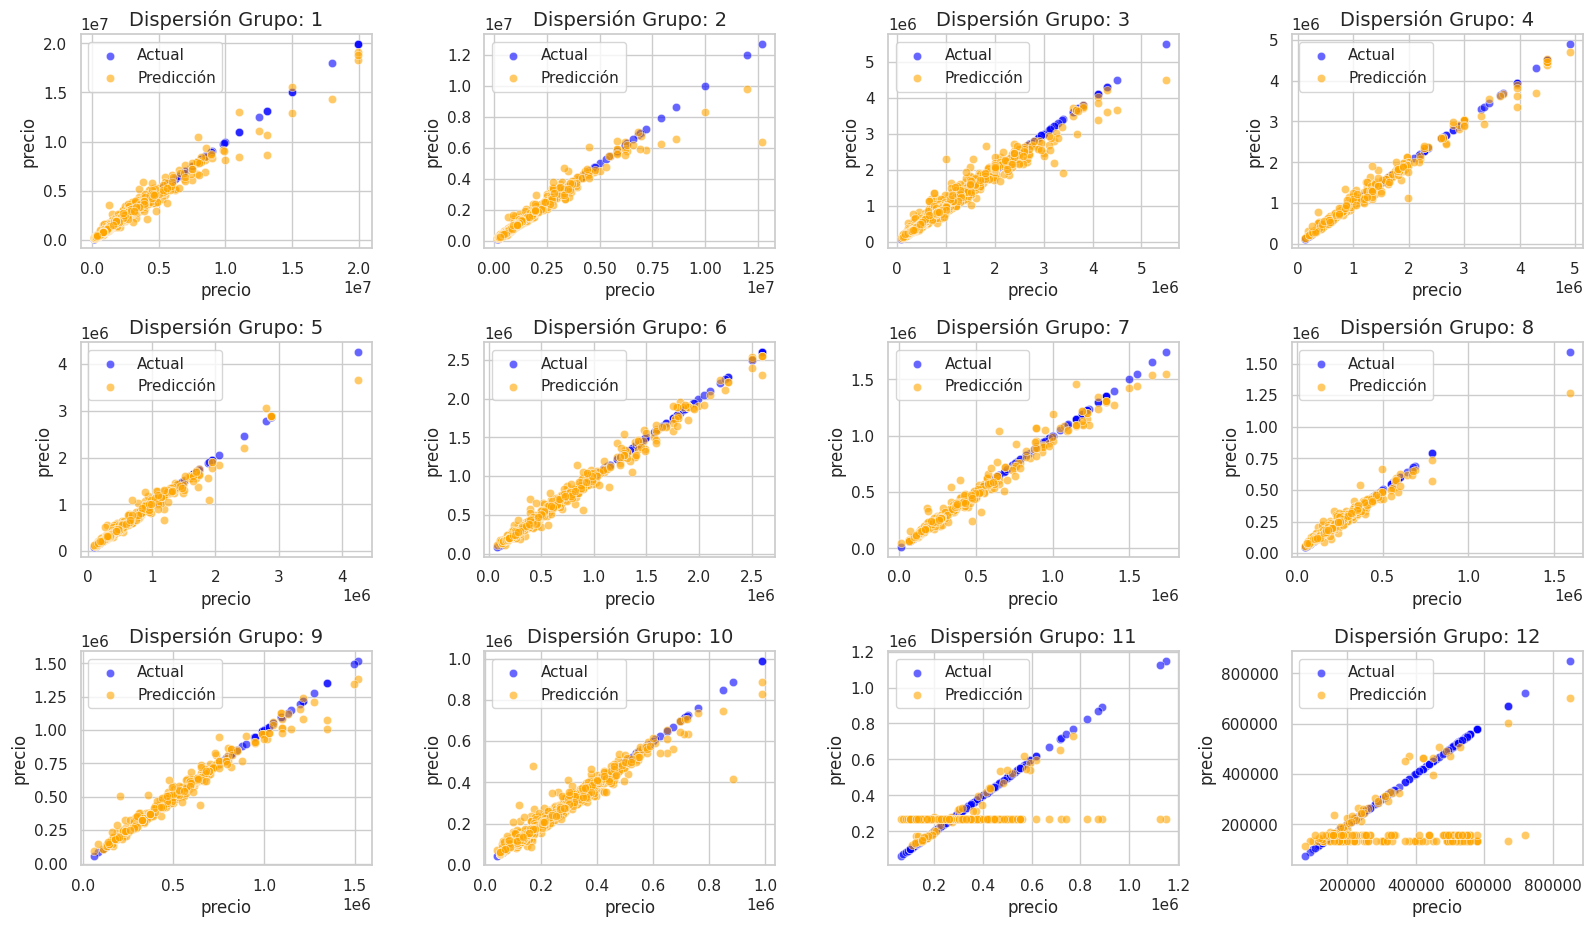

In [61]:
plt.figure(figsize=(16, 12))
sns.set(style="whitegrid")

# Crear los gráficos de dispersión para distintas variables
#variables = ["metros_cuadrados", "precio_m2_distrito", "precio_m2_barrio", "precio_m2_calle"]
for i in np.arange(1,13):
    plt.subplot(4, 4, i)

    # Filtrar por distrito_valor == 1
    df_filtrado = df[df['distrito_valor'] == i]

    # Agregar gráfico de dispersión
    sns.scatterplot(x='precio', y='precio', data=df_filtrado, alpha=0.6, color="blue", label="Actual")
    sns.scatterplot(x='precio', y='precio_pred', data=df_filtrado, alpha=0.6, color="orange", label="Predicción")

    # Configuración del gráfico
    plt.title(f'Dispersión Grupo: {i}', fontsize=14)
    plt.legend()

# Ajustar el diseño del lienzo
plt.tight_layout()
plt.show()

In [ ]:
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,...,precio_m2_distrito,precio_m2_calle,tipo_vivienda_2,segmento,calle_top,distrito_top,barrio_top,distrito_valor,tipo_vivienda_desc,precio_pred
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,...,2.236608,2.717073,pisos,no_top,no_top,no_top,no_top,11,Casa/Chalet,594971.39
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,...,2.236608,2.717073,pisos,no_top,no_top,no_top,no_top,11,Piso,252110.00
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,...,2.236608,1.948505,pisos,no_top,no_top,no_top,no_top,11,Casa/Chalet,523399.40


In [ ]:
df['precio_temp'] = df['precio']
df['precio_pred_temp'] = df['precio_pred']


In [ ]:
df = df.drop('precio', axis=1)
df = df.drop('precio_pred', axis=1)


In [ ]:
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,...,precio_m2_calle,tipo_vivienda_2,segmento,calle_top,distrito_top,barrio_top,distrito_valor,tipo_vivienda_desc,precio_temp,precio_pred_temp
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,...,2.717073,pisos,no_top,no_top,no_top,no_top,11,Casa/Chalet,616300,594971.39
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,...,2.717073,pisos,no_top,no_top,no_top,no_top,11,Piso,274900,252110.00
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,...,1.948505,pisos,no_top,no_top,no_top,no_top,11,Casa/Chalet,519000,523399.40


In [ ]:
df = df.rename(columns={
    'precio_temp': 'precio',
    'precio_pred_temp': 'precio_pred'
})

In [ ]:
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,...,precio_m2_calle,tipo_vivienda_2,segmento,calle_top,distrito_top,barrio_top,distrito_valor,tipo_vivienda_desc,precio,precio_pred
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,...,2.717073,pisos,no_top,no_top,no_top,no_top,11,Casa/Chalet,616300,594971.39
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,...,2.717073,pisos,no_top,no_top,no_top,no_top,11,Piso,274900,252110.00
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,...,1.948505,pisos,no_top,no_top,no_top,no_top,11,Casa/Chalet,519000,523399.40


In [ ]:
df['desviacion'] = np.abs((df['precio_pred'] - df['precio']) / df['precio']) *100
df['desviacion'] = df['desviacion'].astype(int)
df.head(3)


,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,...,tipo_vivienda_2,segmento,calle_top,distrito_top,barrio_top,distrito_valor,tipo_vivienda_desc,precio,precio_pred,desviacion
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,...,pisos,no_top,no_top,no_top,no_top,11,Casa/Chalet,616300,594971.39,3
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,...,pisos,no_top,no_top,no_top,no_top,11,Piso,274900,252110.00,8
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,...,pisos,no_top,no_top,no_top,no_top,11,Casa/Chalet,519000,523399.40,0


In [ ]:
df[df['desviacion'] > 30].count()

sku                        427
metros_cuadrados           427
calle                      427
barrio                     427
distrito                   427
ciudad                     427
tipo_vivienda              427
habitaciones               427
ban                        427
planta                     427
terraza                    427
balcon                     427
ascensor                   427
casa_plantas               427
estado_obra                427
caracteristicas_basicas    427
precio_m2_barrio           427
precio_m2_distrito         427
precio_m2_calle            427
tipo_vivienda_2            427
segmento                   427
calle_top                  427
distrito_top               427
barrio_top                 427
distrito_valor             427
tipo_vivienda_desc         427
precio                     427
precio_pred                427
desviacion                 427
dtype: int64

In [ ]:
df[df['desviacion'] > 30].groupby('ciudad')['precio'].count().reset_index()

,ciudad,precio
0,Alcalá de Henares,82
1,Madrid,221
2,Móstoles,124


In [ ]:
df.groupby('ciudad')['precio'].count().reset_index()

,ciudad,precio
0,Alcalá de Henares,186
1,Madrid,9503
2,Móstoles,206


In [ ]:
'''
dt_todo_top_resumen = df.groupby('distrito')['precio'].agg(
    minimo='min',
    media='mean',
    maximo='max',
    viviendas='count'
).reset_index()
'''

"\ndt_todo_top_resumen = df.groupby('distrito')['precio'].agg(\n    minimo='min', \n    media='mean', \n    maximo='max',\n    viviendas='count'\n).reset_index()\n"

## Valor teorico: Euros/m2 * m2

In [ ]:
df['precio_teorico_m2_distrito'] = df['precio_m2_distrito'] * df['metros_cuadrados'] * 1000
df['precio_teorico_m2_barrio'] = df['precio_m2_barrio'] * df['metros_cuadrados'] * 1000
df['precio_teorico_m2_calle'] = df['precio_m2_calle'] * df['metros_cuadrados'] * 1000


## Guardar las predicciones

In [ ]:
df.to_csv('data/predicciones_madrid.csv', index=False
          )


In [ ]:
df[ (df['desviacion'] > 30) & (df['ciudad'] == 'Alcalá de Henares') ].sort_values(by='desviacion', ascending=False)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,...,distrito_top,barrio_top,distrito_valor,tipo_vivienda_desc,precio,precio_pred,desviacion,precio_teorico_m2_distrito,precio_teorico_m2_barrio,precio_teorico_m2_calle
122,105359657,80,Avenida de nuestra señora de belén,Reyes Católicos,Reyes Católicos,Alcalá de Henares,1.0,3,1,3,...,no_top,no_top,11,Piso,65000,266691.4,310,133663.070539,133663.070539,109044.585987
128,105359541,80,Calle hernando de soto,Reyes Católicos,Reyes Católicos,Alcalá de Henares,1.0,3,1,3,...,no_top,no_top,11,Piso,73000,266691.4,265,133663.070539,133663.070539,73000.000000
132,106262844,78,Calle orquídea,Reyes Católicos,Reyes Católicos,Alcalá de Henares,1.0,3,1,3,...,no_top,no_top,11,Piso,84000,266691.4,217,130321.493776,130321.493776,84000.000000
135,105820070,43,Calle vargas machuca,Reyes Católicos,Reyes Católicos,Alcalá de Henares,1.0,2,1,2,...,no_top,no_top,11,Piso,92500,266691.4,188,71843.900415,71843.900415,92500.000000
150,1628844,35,Calle divino valles,Juan de Austria,Val,Alcalá de Henares,0.0,0,1,3,...,no_top,no_top,11,Estudio,99000,266691.4,169,80674.132330,90019.849785,99000.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,103015062,87,Calle virgen de loreto,El Pilar - Bripac,El Pilar - Bripac,Alcalá de Henares,1.0,3,2,3,...,no_top,no_top,11,Piso,419900,266691.4,36,245675.608716,245675.608716,292395.972870
185,100281273,171,Via complutense,Val,Val,Alcalá de Henares,2.0,3,2,3,...,no_top,no_top,11,Duplex,415000,266691.4,35,394150.760814,372792.873275,415000.000000
170,102932256,136,Calle de braulio vivas,Val,Val,Alcalá de Henares,1.0,4,2,4,...,no_top,no_top,11,Piso,400000,266691.4,33,313476.628484,296490.238394,400000.000000
85,104428365,135,Calle virgen de loreto,El Pilar - Bripac,El Pilar - Bripac,Alcalá de Henares,1.0,4,2,4,...,no_top,no_top,11,Piso,389900,266691.4,31,381220.772146,381220.772146,453717.888936


## Para Alcala de henares y Mostoles, hay que utilizar el precio de m2 por calle y multiplicar por los m2

In [ ]:
lista_val = []

for i in np.arange(0, len(df)):
    if df.loc[i, 'ciudad'] == 'Alcalá de Henares':
        val = df.loc[i, 'precio_teorico_m2_calle']

    elif df.loc[i, 'ciudad'] == 'Móstoles':
        val = df.loc[i, 'precio_teorico_m2_calle']

    elif df.loc[i, 'ciudad'] == 'Madrid':
        val = df.loc[i, 'precio_pred']
    lista_val.append(val)


In [ ]:
df['precio_pred_2'] = lista_val

In [ ]:
df.head(3)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,...,barrio_top,distrito_valor,tipo_vivienda_desc,precio,precio_pred,desviacion,precio_teorico_m2_distrito,precio_teorico_m2_barrio,precio_teorico_m2_calle,precio_pred_2
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,...,no_top,11,Casa/Chalet,616300,594971.39,3,530076.168623,530076.168623,643946.341463,643946.341463
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,...,no_top,11,Piso,274900,252110.00,8,203531.355885,203531.355885,247253.658537,247253.658537
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,...,no_top,11,Casa/Chalet,519000,523399.40,0,599411.026123,599411.026123,522199.252336,522199.252336


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   sku                         9895 non-null   int64  
 1   metros_cuadrados            9895 non-null   int64  
 2   calle                       9895 non-null   object 
 3   barrio                      9895 non-null   object 
 4   distrito                    9895 non-null   object 
 5   ciudad                      9895 non-null   object 
 6   tipo_vivienda               9895 non-null   float64
 7   habitaciones                9895 non-null   int64  
 8   ban                         9895 non-null   int64  
 9   planta                      9895 non-null   int64  
 10  terraza                     9895 non-null   int64  
 11  balcon                      9895 non-null   int64  
 12  ascensor                    9895 non-null   int64  
 13  casa_plantas                9895 

In [ ]:
df['desviacion_2'] = np.abs((df['precio_pred_2'] - df['precio']) / df['precio']) *100
df.head(3)


,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,...,distrito_valor,tipo_vivienda_desc,precio,precio_pred,desviacion,precio_teorico_m2_distrito,precio_teorico_m2_barrio,precio_teorico_m2_calle,precio_pred_2,desviacion_2
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,...,11,Casa/Chalet,616300,594971.39,3,530076.168623,530076.168623,643946.341463,643946.341463,4.485858
1,105997257,91,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,1.0,2,1,2,...,11,Piso,274900,252110.00,8,203531.355885,203531.355885,247253.658537,247253.658537,10.056872
2,106297757,268,El pilar - bripac,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,3,4,...,11,Casa/Chalet,519000,523399.40,0,599411.026123,599411.026123,522199.252336,522199.252336,0.616426


In [ ]:
df[df['desviacion_2'] > 30].groupby('ciudad')['precio_pred_2'].count().reset_index()

,ciudad,precio_pred_2
0,Alcalá de Henares,17
1,Madrid,241
2,Móstoles,20


In [ ]:
df.groupby('ciudad')['precio_pred_2'].count().reset_index()

,ciudad,precio_pred_2
0,Alcalá de Henares,186
1,Madrid,9503
2,Móstoles,206


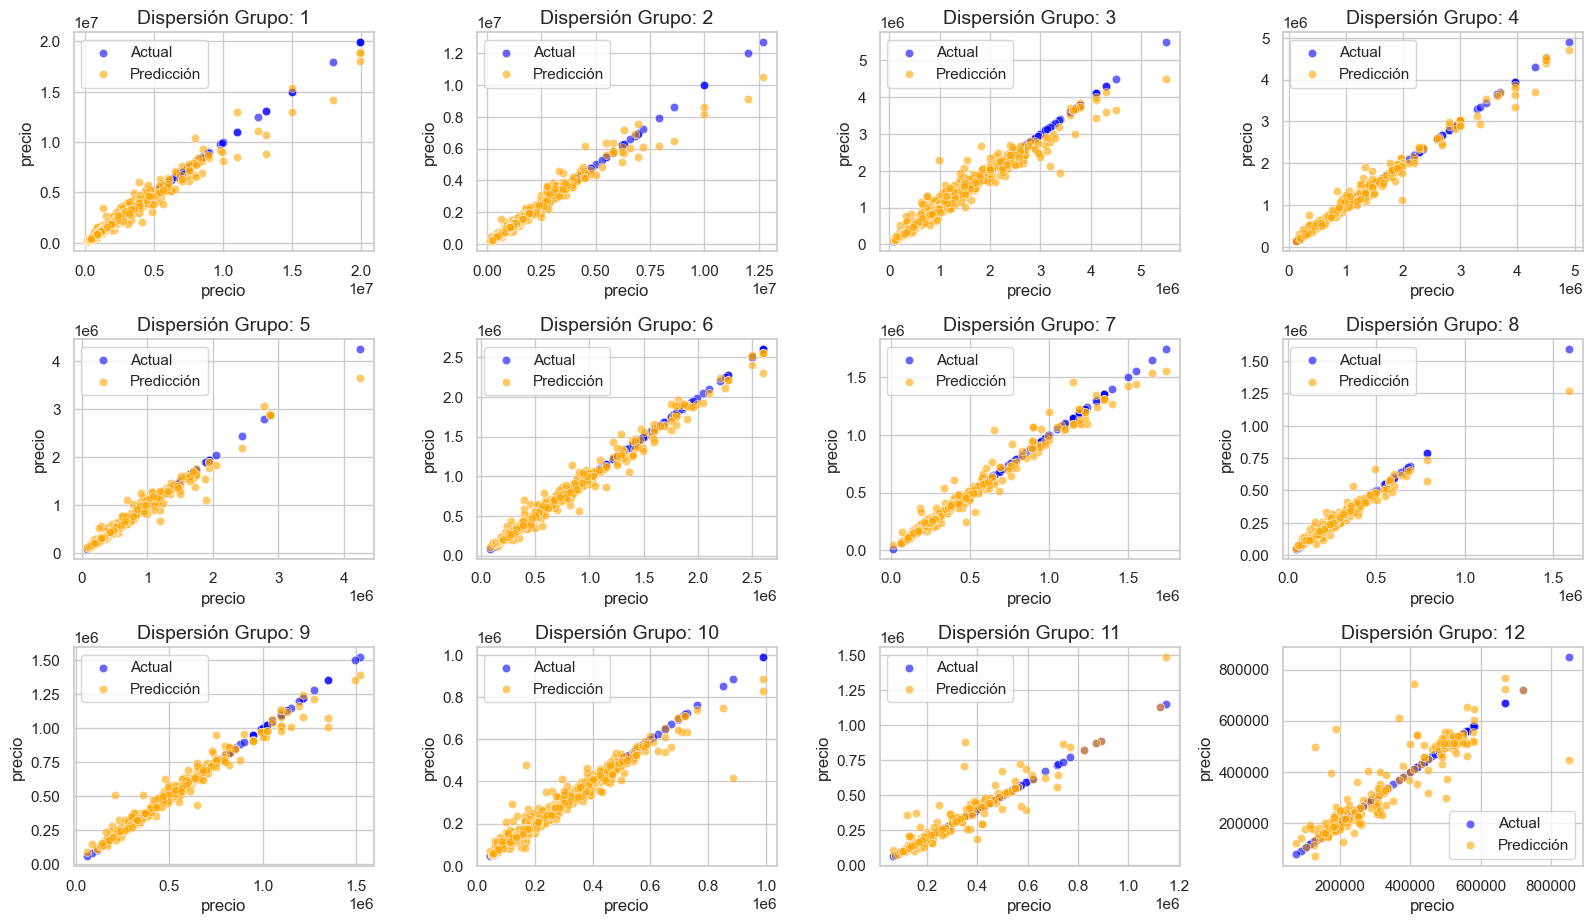

In [ ]:
plt.figure(figsize=(16, 12))
sns.set(style="whitegrid")

# Crear los gráficos de dispersión para distintas variables
#variables = ["metros_cuadrados", "precio_m2_distrito", "precio_m2_barrio", "precio_m2_calle"]
for i in np.arange(1,13):
    plt.subplot(4, 4, i)

    # Filtrar por distrito_valor == 1
    df_filtrado = df[df['distrito_valor'] == i]

    # Agregar gráfico de dispersión
    sns.scatterplot(x='precio', y='precio', data=df_filtrado, alpha=0.6, color="blue", label="Actual")
    sns.scatterplot(x='precio', y='precio_pred_2', data=df_filtrado, alpha=0.6, color="orange", label="Predicción")

    # Configuración del gráfico
    plt.title(f'Dispersión Grupo: {i}', fontsize=14)
    plt.legend()

# Ajustar el diseño del lienzo
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('data/predicciones_madrid.csv', index=False
          )


In [ ]:
df[df['desviacion_2'] > 30].\
        groupby('ciudad').agg({'precio_m2_distrito':"mean",
                                 'precio_m2_barrio':"mean",
                                 'precio_m2_calle':"mean"}).reset_index()


,ciudad,precio_m2_distrito,precio_m2_barrio,precio_m2_calle
0,Alcalá de Henares,2.252940,2.253953,3.500325
1,Madrid,6.457587,6.277095,6.107862
2,Móstoles,2.219979,2.219979,2.790500


In [ ]:
df['metros_cuadrados'].max()

np.int64(995)

## Guardar diccionario de grupos y modelos

In [ ]:
print(grupo_1)
print(grupo_2)
print(grupo_3)
print(grupo_4)
print(grupo_5)
print(grupo_6)
print(grupo_7)
print(grupo_8)
print(grupo_9)
print(grupo_10)
print(grupo_11)
print(grupo_12)


['Salamanca', 'Retiro']
['Chamberí', 'Chamartín']
['Centro']
['Moncloa-Aravaca', 'Fuencarral-El Pardo']
['Tetuán']
['Hortaleza', 'Ciudad Lineal']
['Barajas', 'San Blas-Canillejas', 'Latina']
['Carabanchel']
['Arganzuela']
['Vicálvaro', 'Usera', 'Moratalaz', 'Puente de Vallecas', 'Villaverde']
['Alcalá de Henares']
['Móstoles']


In [ ]:
dis_grupo = grupo_1 + grupo_2  + grupo_3  + grupo_4 + \
            grupo_5 + grupo_6  + grupo_7  + grupo_8 + \
            grupo_9 + grupo_10 + grupo_11 + grupo_12
dis_grupo

['Salamanca',
 'Retiro',
 'Chamberí',
 'Chamartín',
 'Centro',
 'Moncloa-Aravaca',
 'Fuencarral-El Pardo',
 'Tetuán',
 'Hortaleza',
 'Ciudad Lineal',
 'Barajas',
 'San Blas-Canillejas',
 'Latina',
 'Carabanchel',
 'Arganzuela',
 'Vicálvaro',
 'Usera',
 'Moratalaz',
 'Puente de Vallecas',
 'Villaverde',
 'Alcalá de Henares',
 'Móstoles']

In [ ]:
grupos_modelo = ['modelo_1.pkl', 'modelo_1.pkl',
                 'modelo_2.pkl', 'modelo_2.pkl',
                 'modelo_3.pkl',
                 'modelo_4.pkl', 'modelo_4.pkl',
                 'modelo_5.pkl',
                 'modelo_6.pkl', 'modelo_6.pkl',
                 'modelo_7.pkl', 'modelo_7.pkl', 'modelo_7.pkl',
                 'modelo_8.pkl',
                 'modelo_9.pkl',
                 'modelo_10.pkl', 'modelo_10.pkl', 'modelo_10.pkl', 'modelo_10.pkl', 'modelo_10.pkl',
                 'modelo_11.pkl',
                 'modelo_12.pkl']
grupos_modelo

['modelo_1.pkl',
 'modelo_1.pkl',
 'modelo_2.pkl',
 'modelo_2.pkl',
 'modelo_3.pkl',
 'modelo_4.pkl',
 'modelo_4.pkl',
 'modelo_5.pkl',
 'modelo_6.pkl',
 'modelo_6.pkl',
 'modelo_7.pkl',
 'modelo_7.pkl',
 'modelo_7.pkl',
 'modelo_8.pkl',
 'modelo_9.pkl',
 'modelo_10.pkl',
 'modelo_10.pkl',
 'modelo_10.pkl',
 'modelo_10.pkl',
 'modelo_10.pkl',
 'modelo_11.pkl',
 'modelo_12.pkl']

In [ ]:
df['ciudad'].unique()

array(['Alcalá de Henares', 'Madrid', 'Móstoles'], dtype=object)

In [ ]:
len(dis_grupo)-2

20

In [ ]:
ciudad = ['Madrid'] * (len(dis_grupo)-2)
ciudad.append('Alcalá de Henares')
ciudad.append('Móstoles')
ciudad

['Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Madrid',
 'Alcalá de Henares',
 'Móstoles']

In [ ]:
len(ciudad)

22

In [ ]:
len(dis_grupo)

22

In [ ]:
len(grupos_modelo)

22

In [ ]:
tb_grupo_modelo = pd.DataFrame({'ciudad': ciudad, 'distrito': dis_grupo, 'modelo':grupos_modelo})
tb_grupo_modelo

,ciudad,distrito,modelo
0,Madrid,Salamanca,modelo_1.pkl
1,Madrid,Retiro,modelo_1.pkl
2,Madrid,Chamberí,modelo_2.pkl
3,Madrid,Chamartín,modelo_2.pkl
4,Madrid,Centro,modelo_3.pkl
5,Madrid,Moncloa-Aravaca,modelo_4.pkl
6,Madrid,Fuencarral-El Pardo,modelo_4.pkl
7,Madrid,Tetuán,modelo_5.pkl
8,Madrid,Hortaleza,modelo_6.pkl
9,Madrid,Ciudad Lineal,modelo_6.pkl


In [ ]:
tb_grupo_modelo.to_csv('output_deploy/tb_grupo_modelo.csv', index=False, encoding='ISO-8859-1')


##

In [ ]:
df.head(1)

,sku,metros_cuadrados,calle,barrio,distrito,ciudad,tipo_vivienda,habitaciones,ban,planta,...,distrito_valor,tipo_vivienda_desc,precio,precio_pred,desviacion,precio_teorico_m2_distrito,precio_teorico_m2_barrio,precio_teorico_m2_calle,precio_pred_2,desviacion_2
0,100848270,237,Casco histórico,Alcalá de Henares,Alcalá de Henares,Alcalá de Henares,4.0,4,1,4,...,11,Casa/Chalet,616300,594971.39,3,530076.168623,530076.168623,643946.341463,643946.341463,4.485858


In [ ]:
df_rev_barrios = df[df['ciudad']=='Madrid'].groupby(['distrito', 'barrio'])['calle'].count().reset_index().sort_values(by='distrito')
df_rev_barrios

,distrito,barrio,calle
0,Arganzuela,Acacias,44
1,Arganzuela,Arganzuela,43
2,Arganzuela,Chopera,28
3,Arganzuela,Delicias,83
4,Arganzuela,Imperial,106
...,...,...,...
128,Villaverde,Butarque,26
129,Villaverde,Los Rosales,50
130,Villaverde,Los Ángeles,30
131,Villaverde,San Cristóbal,72


In [ ]:
df_rev_barrios.to_csv('revisar_barrios.csv', index=False, encoding='ISO-8859-1')
